In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

# k Nearest Neighbors (kNN)
Метод k ближайших соседей рассчитывает расстояния от нового объекта до всех объектов выборки и, отбирая k ближайших, предсказывает целевую переменную с помощью голосования (в случае классификации) или усреднения (в случае регрессии). \
При этом этот метод можно по-разному настраивать, например можно изменить способ подсчета расстояний или способ взвешивания соседей по расстоянию. \
Для начала скачаем датасет и визуализируем данные.

In [2]:
circ = pd.read_csv('data/concertriccir2.csv')
circ.head()

,X,Y,class
0,0.70,-0.247,0.0
1,-3.95,2.740,1.0
2,0.15,-2.160,1.0
3,-1.67,-0.942,1.0
4,2.56,-1.850,1.0


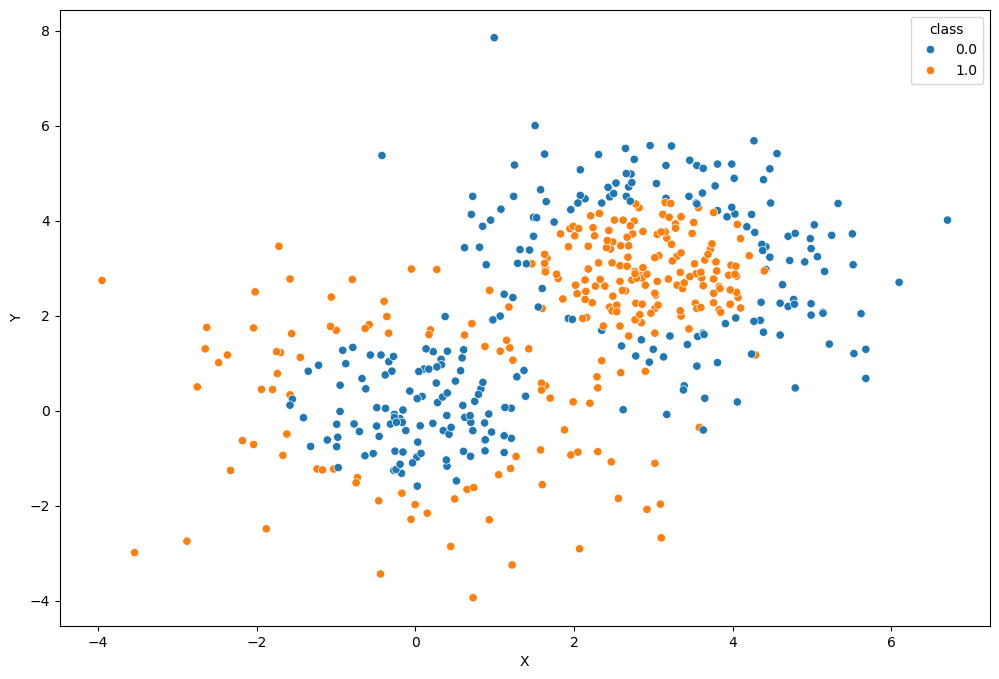

In [3]:
sns.scatterplot(x=circ['X'], y=circ['Y'], hue=circ['class']);

**Задание 1.** Обучите логистическую регрессию на данных и нарисуйте разделяющую гиперплоскость (прямую) на рисунке с данными. Как линейный классификатор справился с задачей? Сделайте вывод исходя из геометрии данных и линии разделения. Какой accuracy выйдет на всей выборке (без валидации)?

In [4]:
from sklearn.linear_model import LogisticRegression

### Your code is here
X=circ.drop('class', axis=1)
y = circ['class']
model = LogisticRegression()
model.fit(X, y)
model.score(X,y)

0.424

<Axes: >

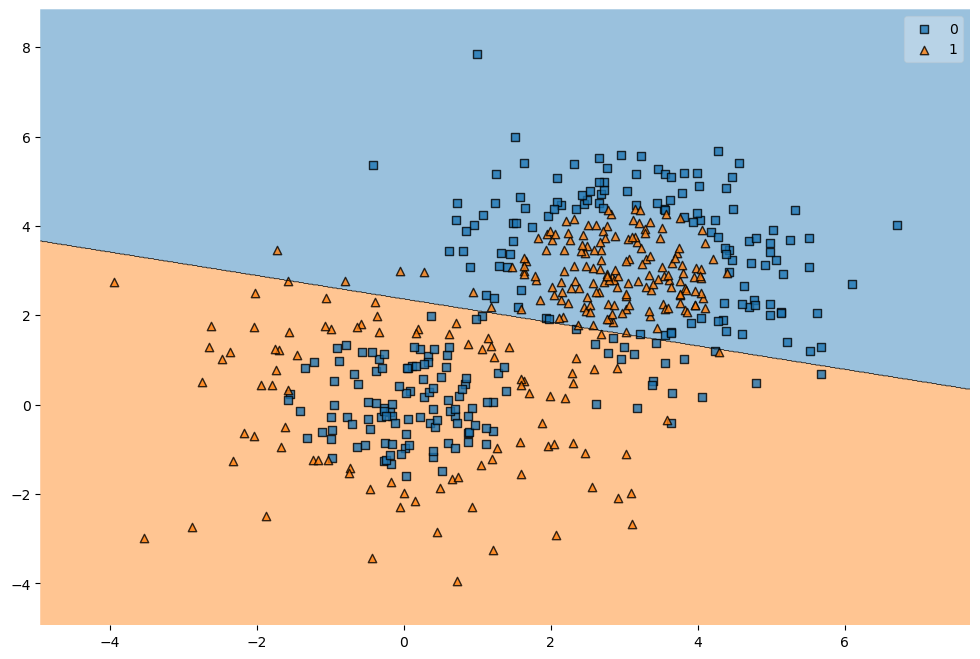

In [5]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X.values, y=y.values.astype(int), clf=model)



In [6]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [7]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

**Задание 2.** Разделите обучающую выборку и обучите 6 моделей kNN с различным числом соседей из `all_k`, сохраните обученные классификаторы в список. \
Выведите accuracy на тренировочной и тестовой выборке для каждой модели. Каково оптимальное число соседей с точки зрения accuracy?

In [8]:
X = circ[['X', 'Y']].values
y = circ['class'].values.astype('int')

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    shuffle=True, random_state=2022)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
all_k = [1, 3, 10, 30, 40, 60]

### Your code is here
for K in all_k:

    knn = KNeighborsClassifier(n_neighbors=K) 
    knn.fit(X_train, y_train)
    
    preds_test = knn.predict(X_test)
    print(f"на трейне для {K} accuracy = {knn.score(X_train, y_train)}")
    print(f"на тесте для {K} accuracy = {knn.score(X_test, y_test)}")



на трейне для 1 accuracy = 1.0
на тесте для 1 accuracy = 0.89
на трейне для 3 accuracy = 0.9475
на тесте для 3 accuracy = 0.87
на трейне для 10 accuracy = 0.915
на тесте для 10 accuracy = 0.85
на трейне для 30 accuracy = 0.8525
на тесте для 30 accuracy = 0.74
на трейне для 40 accuracy = 0.8
на тесте для 40 accuracy = 0.75
на трейне для 60 accuracy = 0.6925
на тесте для 60 accuracy = 0.73


**Задание 3.** (бонусное) Скачайте библиотку [mlxtend](http://rasbt.github.io/mlxtend/#examples) для визуализации решающих поверхностей. 
В документации можно ознакомиться с [примерами](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) изображения решающих поверхностей для различных моделей. \
Построим несколько таких графиков для шести обученных нами kNN.

1. Подберите параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов. 
2. Удобно перед визулизацией сохранить обученные классификаторы в список `all_clfs`.
3. Проявите терпение! Отрисовка решающих поверхностей может занимать пару минут.

In [11]:
import mlxtend
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools

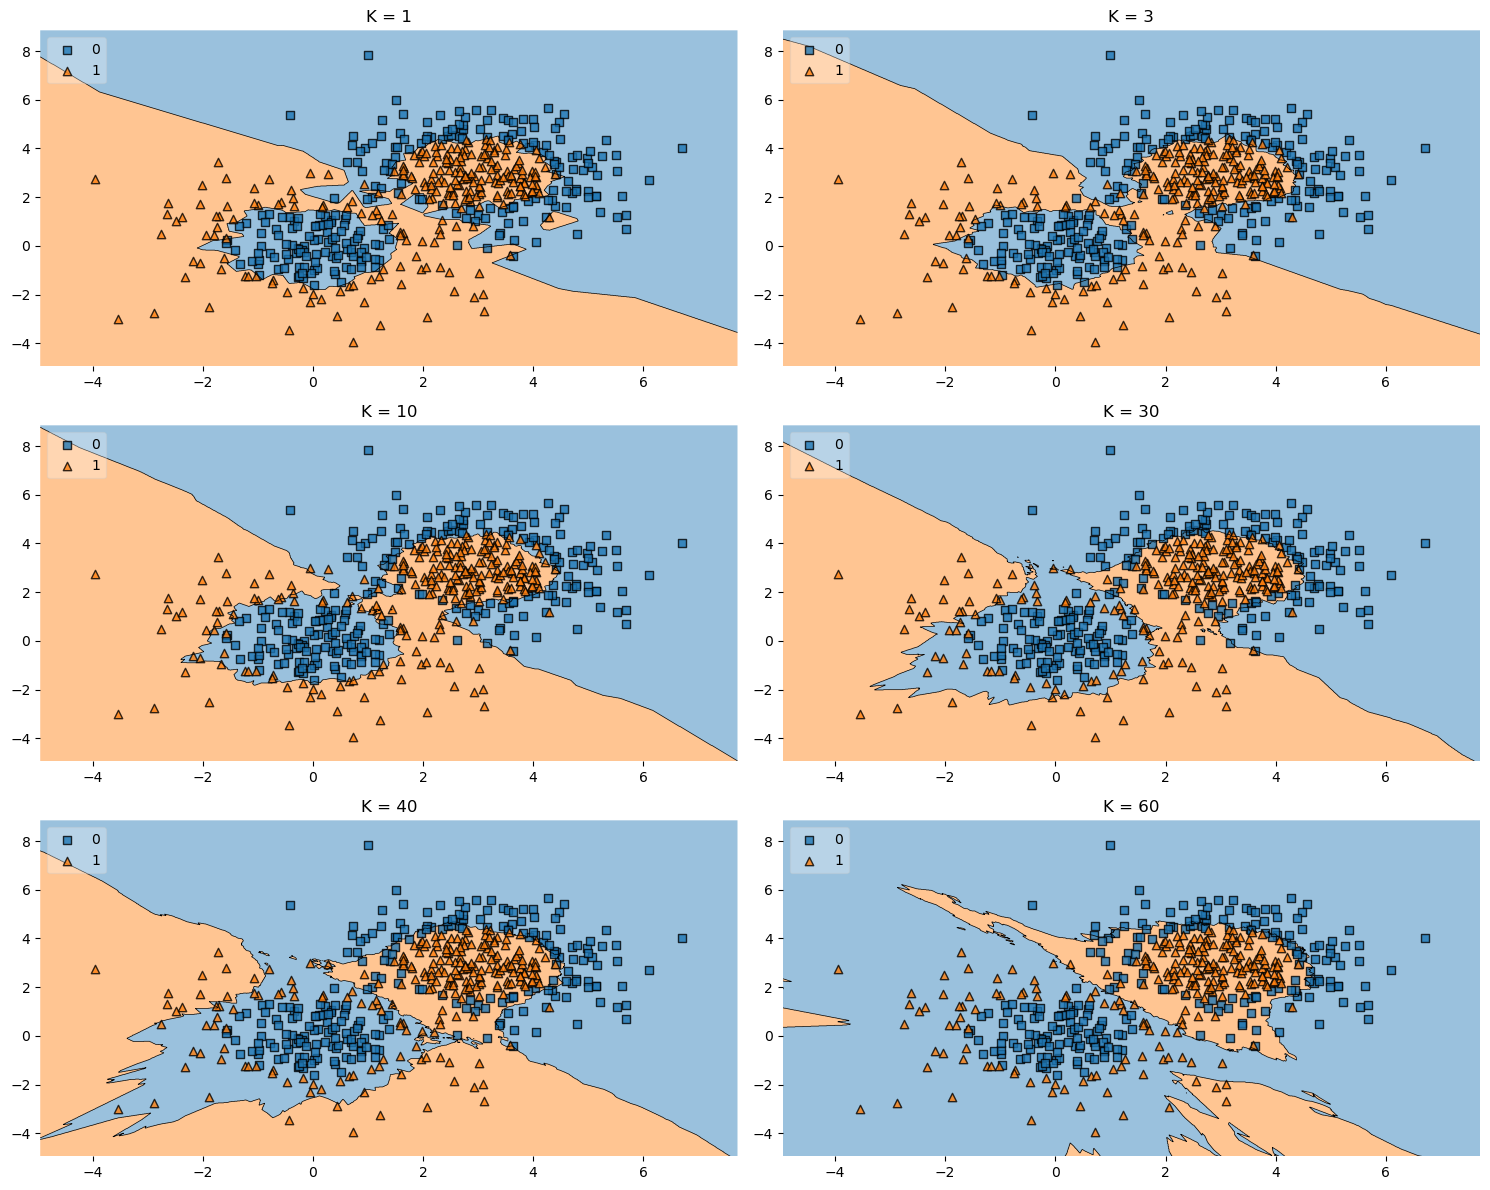

In [12]:
gs = gridspec.GridSpec(3, 2)
fig = plt.figure(figsize=(15, 12))

all_k = [1, 3, 10, 30, 40, 60]

# Создаем правильные координаты для сетки 3x2
grid_positions = list(itertools.product([0, 1, 2], [0, 1]))

for K, grd in zip(all_k, grid_positions):
    knn = KNeighborsClassifier(n_neighbors=K)  # Используем K вместо x
    knn.fit(X_train, y_train)
    
    ax = plt.subplot(gs[grd[0], grd[1]])
    
    
    plot_decision_regions(X=X, y=y, clf=knn, legend=2, ax=ax)
    ax.set_title(f'K = {K}')
    
plt.tight_layout()
plt.show()

1. Как меняется решающая поверхность с ростом числа соседей?
2. Какое оптимальное число соседей с точки зрения устройства данных и геометрии решающих поверхностей? Поясните свой ответ, опираясь на полученные графики.
3. Лучше ли справляется kNN по сравнению с логистической регрессией?

**Задание 4.** Скачайте уже известный вам датасет [SigmaCabs](https://www.kaggle.com/datasets/arashnic/taxi-pricing-with-mobility-analytics). Обучите классификатор kNN на отнормированных и не отнормированных данных, подобрав лучшие гиперпараметры среди $k \in [1, 5, 10]$. Замерьте качество на тестовой выборке. \
Почему нормирование данных помогает улучшить качество?

In [13]:
df = pd.read_csv('data/processed_sigma_cabs.csv')
df.head()

,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Surge_Pricing_Type,Type_of_Cab_B,...,Destination_Type_F,Destination_Type_G,Destination_Type_H,Destination_Type_I,Destination_Type_J,Destination_Type_K,Destination_Type_L,Destination_Type_M,Destination_Type_N,Gender_Male
0,6.77,1.0,2.42769,3.90500,0,40.0,46,60,2,1,...,0,0,0,0,0,0,0,0,0,0
1,29.47,10.0,2.78245,3.45000,0,38.0,56,78,2,1,...,0,0,0,0,0,0,0,0,0,1
2,41.58,10.0,2.79805,3.50125,2,61.0,56,77,2,1,...,0,0,0,0,0,0,0,0,0,1
3,61.56,10.0,2.79805,3.45375,0,61.0,52,74,3,0,...,0,0,0,0,0,0,0,0,0,1
4,54.95,10.0,3.03453,3.40250,4,51.0,49,102,2,0,...,0,0,0,0,0,0,0,0,0,1


In [14]:
X = df.drop('Surge_Pricing_Type', axis=1)
y = df['Surge_Pricing_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    shuffle=True, random_state=2022)

In [15]:
### Your code is here
k_num = [1,5,10]
for K in k_num:
    knn = KNeighborsClassifier(n_neighbors=K) 
    knn.fit(X_train, y_train)
    
    preds_test = knn.predict(X_test)
    print(f"на трейне для {K} accuracy = {knn.score(X_train, y_train)}")
    print(f"на тесте для {K} accuracy = {knn.score(X_test, y_test)}")




на трейне для 1 accuracy = 1.0
на тесте для 1 accuracy = 0.43819542019519236
на трейне для 5 accuracy = 0.6302917525088058
на тесте для 5 accuracy = 0.44317016671097104
на трейне для 10 accuracy = 0.5848626684009153
на тесте для 10 accuracy = 0.4703603843086621


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Масштабируем только признаки (X), НЕ целевые переменные (y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # важно: transform, а не fit_transform!

k_num = [1, 5, 10]
for K in k_num:
    knn = KNeighborsClassifier(n_neighbors=K) 
    knn.fit(X_train_scaled, y_train)  # используем масштабированные данные
    
    # Для тестовых данных тоже используем масштабированные версии
    train_accuracy = knn.score(X_train_scaled, y_train)
    test_accuracy = knn.score(X_test_scaled, y_test)
    
    print(f"K = {K}:")
    print(f"  Тренировочная accuracy = {train_accuracy:.4f}")
    print(f"  Тестовая accuracy = {test_accuracy:.4f}")
    print("-" * 40)

K = 1:
  Тренировочная accuracy = 1.0000
  Тестовая accuracy = 0.5649
----------------------------------------
K = 5:
  Тренировочная accuracy = 0.7349
  Тестовая accuracy = 0.6304
----------------------------------------
K = 10:
  Тренировочная accuracy = 0.7076
  Тестовая accuracy = 0.6608
----------------------------------------


**Задание 5.** Обучите классификатор kNN на отнормированных данных с помощью метрики Минковского. 
$$
\rho(x, z) = \bigg(\sum_i |x_i - z_i|^p\bigg) ^{1/p}
$$

Значение параметра `p` возьмите равным единице. Замерьте качество на тестовой выборке и сравните с предыдущим заданием, где `p = 2`.

In [17]:
### Your code is here
k_num = [1, 5, 10]
for K in k_num:
    knn = KNeighborsClassifier(n_neighbors=K, metric='minkowski',  p=1)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    knn.fit(X_train_scaled, y_train)

    train_accuracy = knn.score(X_train_scaled, y_train)
    test_accuracy = knn.score(X_test_scaled, y_test)
    
    print(f"K = {K}:")
    print(f"  Тренировочная accuracy = {train_accuracy:.4f}")
    print(f"  Тестовая accuracy = {test_accuracy:.4f}")
    print("-" * 40)

K = 1:
  Тренировочная accuracy = 1.0000
  Тестовая accuracy = 0.5643
----------------------------------------
K = 5:
  Тренировочная accuracy = 0.7344
  Тестовая accuracy = 0.6270
----------------------------------------
K = 10:
  Тренировочная accuracy = 0.7077
  Тестовая accuracy = 0.6611
----------------------------------------


**Задание 6.** Скачайте датасет [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices), в котором мы будем предсказывать среднюю стоимость жилья. В качестве признаков будем использовать `['longitude', 'latitude']`, посмотрите на них с помощью scatterplot. \
По какой характеристике наш kNN регрессор в этом случае подбирает соседей?

1. Обучите обыкновенную линейную регрессию и замерьте RMSE на тренировочной и тестовой выборках.
2. Обучите kNN регрессор на отнормированных данных, подобрав лучшие гиперпараметры $k \in [1, 2, ..., 9]$. 
3. Обучите kNN регрессор с гауссовским ядром, взяв параметр k из предыдущего пункта и подобрав оптимальное значение ширины окна среди предложенных $h \in np.arange(0.02, 0.1, 0.01)$.

Как ширина окна влияет на веса при усреднении ответа по соседям? 

In [18]:
df = pd.read_csv('data/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


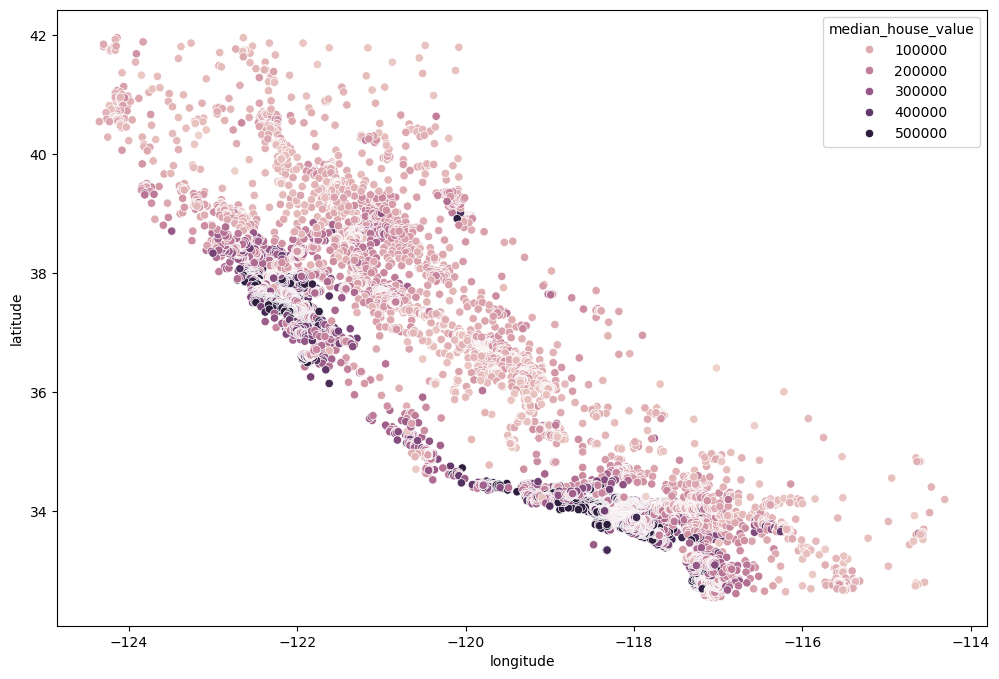

In [19]:
X = df[['longitude', 'latitude']]
y = df['median_house_value']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    shuffle=True, random_state=2022)
sns.scatterplot(x='longitude', y='latitude', data=X, hue=y);

In [20]:
### 1. Обучите обыкновенную линейную регрессию и замерьте RMSE на тренировочной и тестовой выборках.
from sklearn.linear_model import LinearRegression
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)  

print(f"Среднее RMSE линейной модели без скалирования на трейне: {np.sqrt(np.mean((model_lr.predict(X_train) - y_train)**2)).round(3)}")
print(f"Среднее RMSE линейной модели без скалирования на тесте: {np.sqrt(np.mean((model_lr.predict(X_test) - y_test)**2)).round(3)}")


Среднее RMSE линейной модели без скалирования на трейне: 100948.4
Среднее RMSE линейной модели без скалирования на тесте: 98369.877


In [21]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import PredefinedSplit

test_fold = [0 if x in X_train.index else -1 for x in X.index]
ps = PredefinedSplit(test_fold)

linear_cv = cross_validate(model_lr, X, y, cv=ps, scoring='neg_mean_squared_error', return_train_score=True)
rmse_cv_train = np.sqrt(-linear_cv['train_score'].mean())
rmse_cv_test = np.sqrt(-linear_cv['test_score'].mean())
print(f"Среднее RMSE линейной модели без скалирования на трейне: {rmse_cv_train.round(3)}")
print(f"Среднее RMSE линейной модели без скалирования на тесте: {rmse_cv_test.round(3)}")

Среднее RMSE линейной модели без скалирования на трейне: 98340.968
Среднее RMSE линейной модели без скалирования на тесте: 100976.692


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe_lr = Pipeline([('scaler', StandardScaler()),
                    ('model_lr', LinearRegression())])
pipe_lr.fit(X_train, y_train)
linear_cv = cross_validate(pipe_lr, X, y, cv=ps, scoring='neg_mean_squared_error', return_train_score=True)
rmse_cv_train = np.sqrt(-linear_cv['train_score'].mean())
rmse_cv_test = np.sqrt(-linear_cv['test_score'].mean())
print(f"Среднее RMSE линейной модели cо скалированием на трейне: {rmse_cv_train.round(3)}")
print(f"Среднее RMSE линейной модели cо скалированием на тесте: {rmse_cv_test.round(3)}")

Среднее RMSE линейной модели cо скалированием на трейне: 98340.968
Среднее RMSE линейной модели cо скалированием на тесте: 100976.692


In [23]:
np.linspace(1, 9, 9, dtype=int)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [24]:
### 2. Обучите kNN регрессор на отнормированных данных, подобрав лучшие гиперпараметры
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np


pipe_knn = Pipeline([('scaler', StandardScaler()),
                     ('model_knn', KNeighborsRegressor())])
param_grid = {
    'model_knn__n_neighbors': np.linspace(1, 9, 9, dtype=int)
}


search = GridSearchCV(pipe_knn, param_grid, cv=ps, scoring='neg_mean_squared_error', return_train_score=True)

search.fit(X, y)
print(search.best_params_)


best_estimator = search.best_estimator_
cv_results_best = cross_validate(
    best_estimator, 
    X, y, 
    cv=ps, 
    scoring='neg_mean_squared_error', 
    return_train_score=True
)

rmse_cv_train_mean = np.sqrt(-cv_results_best['train_score'].mean())
rmse_cv_test_mean = np.sqrt(-cv_results_best['test_score'].mean())

print(f"\nСреднее RMSE лучшей kNN модели на трейне: {rmse_cv_train_mean.round(3)}")
print(f"Среднее RMSE лучшей kNN модели на тесте: {rmse_cv_test_mean.round(3)}")


{'model_knn__n_neighbors': 5}

Среднее RMSE лучшей kNN модели на трейне: 48593.384
Среднее RMSE лучшей kNN модели на тесте: 61031.665


In [25]:
np.arange(0.02, 0.1, 0.01)

array([0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09])

In [26]:
### 3.Обучите kNN регрессор с гауссовским ядром,
### взяв параметр k из предыдущего пункта 
### и подобрав оптимальное значение ширины окна среди предложенных
from functools import partial

results_test_rmse_dict = {}

def kernel(distances, h):
    
        const = 1 / (np.sqrt(2 * np.pi))
        power = (-1/2) * ((distances)**2) / h**2
    
        return const * np.exp(power)

for h in np.arange(0.02, 0.1, 0.01):
    pipe_knn_kernel = Pipeline([
    ('scaler', StandardScaler()),
    ('KNN', KNeighborsRegressor(n_neighbors=5, weights=partial(kernel, h=h)))
    ])

    cv_results = cross_validate(
    pipe_knn_kernel, 
    X, y, 
    cv=ps, 
    scoring='neg_mean_squared_error', 
    return_train_score=True
    )
    
    rmse_cv_train_mean = np.sqrt(-cv_results['train_score'].mean())
    rmse_cv_test_mean = np.sqrt(-cv_results['test_score'].mean())

    results_test_rmse_dict[h] = round(rmse_cv_test_mean, 3) 

    print(f"\nСреднее RMSE kNN модели c шириной окна {h.round(2)} на трейне: {rmse_cv_train_mean.round(3)}")
    print(f"Среднее RMSE kNN модели c шириной окна {h.round(2)} на тесте: {rmse_cv_test_mean.round(3)}")


print("h for best test rmse:", min(results_test_rmse_dict, key=results_test_rmse_dict.get))
max(results_test_rmse_dict.values())


Среднее RMSE kNN модели c шириной окна 0.02 на трейне: 44262.114
Среднее RMSE kNN модели c шириной окна 0.02 на тесте: 60678.251

Среднее RMSE kNN модели c шириной окна 0.03 на трейне: 46050.223
Среднее RMSE kNN модели c шириной окна 0.03 на тесте: 60790.951

Среднее RMSE kNN модели c шириной окна 0.04 на трейне: 46917.254
Среднее RMSE kNN модели c шириной окна 0.04 на тесте: 60853.069

Среднее RMSE kNN модели c шириной окна 0.05 на трейне: 47410.469
Среднее RMSE kNN модели c шириной окна 0.05 на тесте: 60886.644

Среднее RMSE kNN модели c шириной окна 0.06 на трейне: 47710.374
Среднее RMSE kNN модели c шириной окна 0.06 на тесте: 60906.763

Среднее RMSE kNN модели c шириной окна 0.07 на трейне: 47904.481
Среднее RMSE kNN модели c шириной окна 0.07 на тесте: 60921.678

Среднее RMSE kNN модели c шириной окна 0.08 на трейне: 48038.722
Среднее RMSE kNN модели c шириной окна 0.08 на тесте: 60934.177

Среднее RMSE kNN модели c шириной окна 0.09 на трейне: 48136.65
Среднее RMSE kNN модели c

60945.231